In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
# 导入进度条可视化工具tqdm，用于显示数据集下载进度
from torchvision.datasets.utils import tqdm

# from pytorch.MNIST import criterion, running_loss, predicted

# 备用导入方案：若上一行报错，取消注释使用该行，通用的进度条库
from tqdm import tqdm

# 定义图像预处理流程：将多个操作组合成串行流程
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像/ numpy数组转换为PyTorch张量，像素值归一化至[0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 归一化：将张量值从[0,1]缩放到[-1,1]
])

# 设置批次大小：每次加载4张图片进行训练/测试
batch_size = 4

# ===================== 数据集下载进度可视化模块 =====================
# 保存CIFAR10原始的下载方法，避免覆盖后无法调用
original_download = torchvision.datasets.CIFAR10.download

# 自定义下载函数，在原有下载逻辑基础上增加提示文字
def patched_download(self):
    # 打印下载开始提示
    print("\n📥 开始下载 CIFAR-10 数据集...")
    # 调用PyTorch原生的下载方法，自动显示下载进度条
    original_download(self)
    # 打印下载/校验完成提示
    print("✅ 数据集下载/校验完成！\n")

# 将自定义的下载函数替换掉原生的下载函数，实现可视化效果
torchvision.datasets.CIFAR10.download = patched_download
# ==================================================================

# 加载CIFAR10训练数据集
trainset = torchvision.datasets.CIFAR10(
    root='./data',        # 数据集存放的根目录
    train=True,           # True表示加载训练集（共50000张图片）
    download=True,        # True表示本地无数据集时自动下载
    transform=transform   # 对图像应用定义好的预处理操作
)
# 定义训练集数据加载器：批量读取数据，用于模型训练
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,  # 每批次加载的图片数量
    shuffle=True,           # 打乱训练集数据顺序，提升模型泛化能力
    num_workers=0           # Windows系统必须设为0，关闭多线程避免报错
)

# 加载CIFAR10测试数据集
testset = torchvision.datasets.CIFAR10(
    root='./data',        # 与训练集使用同一存储路径
    train=False,          # False表示加载测试集（共10000张图片）
    download=True,        # 自动下载测试集
    transform=transform   # 测试集图像使用与训练集相同的预处理
)
# 定义测试集数据加载器：批量读取数据，用于模型评估
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,  # 批次大小与训练集保持一致
    shuffle=False,          # 测试集无需打乱顺序
    num_workers=0           # Windows系统多线程设置
)

# CIFAR10数据集的10个类别名称，与标签数字0-9一一对应
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


📥 开始下载 CIFAR-10 数据集...
✅ 数据集下载/校验完成！


📥 开始下载 CIFAR-10 数据集...
✅ 数据集下载/校验完成！



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5..2.5].


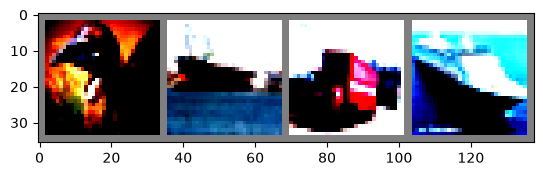

bird  ship  truck ship 


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img * 2 + 0.5  # 反归一化，将张量值从[-1,1]恢复到[0,1]
    npimg = img.numpy()  # 将PyTorch张量转换为NumPy数组
    # 使用matplotlib显示图像，注意需要将通道维度从(3, H, W)转换为(H, W, 3)
    plt.imshow(npimg.transpose((1, 2, 0)))
    plt.show() # 显示图像

## 获取训练集中的一批数据
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [3]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # 第一层卷积层
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool = nn.MaxPool2d(2, 2)
        # 第二层卷积层
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        # 第一层全连接层：输入为16个5x5的特征图，输出为120个神经元
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # 卷据积 -> 激活 -> 池化
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # 将多维张量展平为一维向量，便于输入全
        x = torch.flatten(x, 1) # 展平所有维度，除了批次维度
        # 全连接层 -> 激活
        x = F.relu(self.bn3(self.fc1(x)))
        x = F.relu(self.fc2(x))
        # 输出层
        x = self.fc3(x)
        return x

net = Net().to(device)

使用设备: cuda


In [4]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()  # 定义损失函数为交叉熵损失
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)  # 定义优化器为随机梯度下降，学习率为0.001，动量为0.9
optimizer = optim.Adam(net.parameters(), lr=0.001)  # 定义优化器为Adam，学习率为0.001

In [5]:
# 训练网络
print("🚀 开始训练网络...")
num_epochs = 2

for epoch in range(num_epochs):
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        input, labels = data
        input, labels = input.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = net(input)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}")
    print("Finished Training")

🚀 开始训练网络...
Epoch [1/2], Loss: 1.7194
Finished Training
Epoch [2/2], Loss: 1.5172
Finished Training


In [6]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5..2.5].


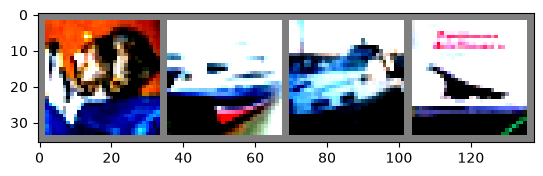

GroundTruth:  cat   ship  ship  plane
Predicted:  cat   car   deer  plane


In [7]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

net = Net().to(device)

net.load_state_dict(torch.load(PATH, weights_only=True))

images = images.to(device)
labels = labels.to(device)

outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(batch_size)))

In [8]:
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%')

Accuracy of the network on the 10000 test images: 48.00%
